In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-Learn version: {sklearn.__version__}")

All libraries imported successfully.
Pandas version: 3.0.3
Scikit-Learn version: 1.9.0


## 1. Baseline Data Ingestion (CIC-IDS-2017)
In this section, we load the historical baseline telemetry by extracting random samples of 10,000 records from each day of the capture week.

In [3]:
import pandas as pd
import os

print("--- Loading Baseline Telemetry (CIC-IDS-2017) ---")
dir_2017 = '../data/CIC-IDS-2017/'

files_2017 = [
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
]

df_list_2017 = []

for file in files_2017:
    file_path = os.path.join(dir_2017, file)
    try:
        df_temp = pd.read_csv(file_path).sample(n=10000, random_state=42)
        df_list_2017.append(df_temp)
        print(f"Loaded sample from: {file}")
    except FileNotFoundError:
        print(f"[ERROR] Could not find {file_path}.")

# Store in memory as a single dataframe
df_2017 = pd.concat(df_list_2017, ignore_index=True)
df_2017.columns = df_2017.columns.str.strip()

print(f"\nTotal 2017 Dataset Shape: {df_2017.shape}")

--- Loading Baseline Telemetry (CIC-IDS-2017) ---
Loaded sample from: Monday-WorkingHours.pcap_ISCX.csv
Loaded sample from: Tuesday-WorkingHours.pcap_ISCX.csv
Loaded sample from: Wednesday-workingHours.pcap_ISCX.csv
Loaded sample from: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loaded sample from: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loaded sample from: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loaded sample from: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loaded sample from: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv

Total 2017 Dataset Shape: (80000, 79)


## 2. Preprocessing & Scaling (2017 Baseline)
DBSCAN requires purely numerical, standardized data to compute spatial distances accurately. Here, we isolate our target labels, sanitize corrupted artifacts (e.g., infinite values produced by CICFlowMeter), and apply standard scaling to the feature matrix.

In [4]:
import numpy as np
from sklearn.preprocessing import StandardScaler

print("--- Cleaning and Scaling 2017 Baseline ---")

y_2017 = df_2017['Label']
X_2017 = df_2017.drop(columns=['Label'])

# Sanitize memory
X_2017 = X_2017.replace([np.inf, -np.inf], np.nan)
valid_indices_2017 = X_2017.dropna().index
X_2017 = X_2017.loc[valid_indices_2017]
y_2017 = y_2017.loc[valid_indices_2017]

X_2017 = X_2017.select_dtypes(include=[np.number])

# Mathematically scale the data and overwrite the variable
scaler_2017 = StandardScaler()
X_scaled_2017 = scaler_2017.fit_transform(X_2017)

print(f"2017 Preprocessing Complete. Final Matrix Shape: {X_scaled_2017.shape}")

--- Cleaning and Scaling 2017 Baseline ---
2017 Preprocessing Complete. Final Matrix Shape: (79928, 78)


## 3. Real-World Telemetry Ingestion (LUFlow 2022)
To contrast our controlled lab baseline, we ingest real-world honeypot telemetry from the LUFlow dataset. We extract a proportional sample of 80,000 records to maintain statistical parity with the 2017 dataset.

In [5]:
import pandas as pd

print("--- Loading Real-World Telemetry (LUFlow 2022) ---")
file_2022 = '../data/LUFlow-2022/2022.06.14.csv'

try:
    df_2022 = pd.read_csv(file_2022).sample(n=80000, random_state=42)
    print(f"2022 Dataset Shape: {df_2022.shape}")
    
    if 'label' in df_2022.columns:
        print("\n2022 Target Distribution:")
        print(df_2022['label'].value_counts())
    else:
        print("Warning: 'label' column not found.")
except FileNotFoundError:
    print(f"[ERROR] Could not find {file_2022}.")

--- Loading Real-World Telemetry (LUFlow 2022) ---
2022 Dataset Shape: (80000, 16)

2022 Target Distribution:
label
benign     40072
outlier    39928
Name: count, dtype: int64


## 4. Preprocessing & Scaling (LUFlow 2022)
We apply the identical preprocessing pipeline to the modern telemetry. String-based metadata (such as IP addresses) is stripped, and the continuous features are standardized to unit variance.

In [6]:
import numpy as np
from sklearn.preprocessing import StandardScaler

print("--- Cleaning and Scaling 2022 Real-World Telemetry ---")

if 'label' in df_2022.columns:
    y_2022 = df_2022['label']
    X_2022 = df_2022.drop(columns=['label'])
else:
    y_2022 = None
    X_2022 = df_2022.copy()

X_2022 = X_2022.replace([np.inf, -np.inf], np.nan)
valid_indices_2022 = X_2022.dropna().index
X_2022 = X_2022.loc[valid_indices_2022]

if y_2022 is not None:
    y_2022 = y_2022.loc[valid_indices_2022]

X_2022 = X_2022.select_dtypes(include=[np.number])

scaler_2022 = StandardScaler()
X_scaled_2022 = scaler_2022.fit_transform(X_2022)

print(f"2022 Preprocessing Complete. Final Matrix Shape: {X_scaled_2022.shape}")

--- Cleaning and Scaling 2022 Real-World Telemetry ---
2022 Preprocessing Complete. Final Matrix Shape: (73429, 15)


## 5. Exploratory Data Analysis (EDA) & Statistical Summary
Before applying the DBSCAN algorithm, we must understand the statistical distributions and characteristics of our datasets. This section extracts a statistical summary of the features and visualizes the heavy class imbalances present in both historical and modern network telemetry.

--- 2017 Baseline: First 5 Rows (Truncated) ---


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min
0,80,5271779,3,1,12,0,6,0
1,443,153756,10,5,1140,943,901,0
2,443,312614,15,10,974,7387,469,0
3,53,62774,2,2,64,200,32,32
4,123,68044766,2,2,96,96,48,48



--- 2017 Baseline: Statistical Summary (Mean, Std, Min, Max) ---


,count,mean,std,min,25%,50%,75%,max
Destination Port,80000.0,8.191298e+03,1.825881e+04,0.0,53.0,80.0,4.450000e+02,6.552000e+04
Flow Duration,80000.0,1.280371e+07,3.149794e+07,0.0,147.0,31164.0,1.678878e+06,1.199999e+08
Total Fwd Packets,80000.0,5.782875e+00,4.090605e+01,1.0,1.0,2.0,4.000000e+00,8.304000e+03
Total Backward Packets,80000.0,5.624912e+00,4.859914e+01,0.0,1.0,2.0,4.000000e+00,7.879000e+03
Total Length of Fwd Packets,80000.0,5.175131e+02,3.073360e+03,0.0,6.0,56.0,1.290000e+02,3.432130e+05
Total Length of Bwd Packets,80000.0,5.490166e+03,9.969013e+04,0.0,6.0,116.0,3.940000e+02,2.010000e+07
Fwd Packet Length Max,80000.0,2.101331e+02,7.888717e+02,0.0,6.0,35.0,5.600000e+01,1.606000e+04
Fwd Packet Length Min,80000.0,1.941746e+01,6.550131e+01,0.0,0.0,6.0,3.600000e+01,1.983000e+03
Fwd Packet Length Mean,80000.0,6.073981e+01,2.082799e+02,0.0,6.0,32.0,4.800000e+01,3.968143e+03
Fwd Packet Length Std,80000.0,7.043193e+01,3.198532e+02,0.0,0.0,0.0,1.443376e+01,5.796501e+03



--- Generating Target Distribution Graphs ---
--- Saving EDA Figures to outputs/figures/ ---


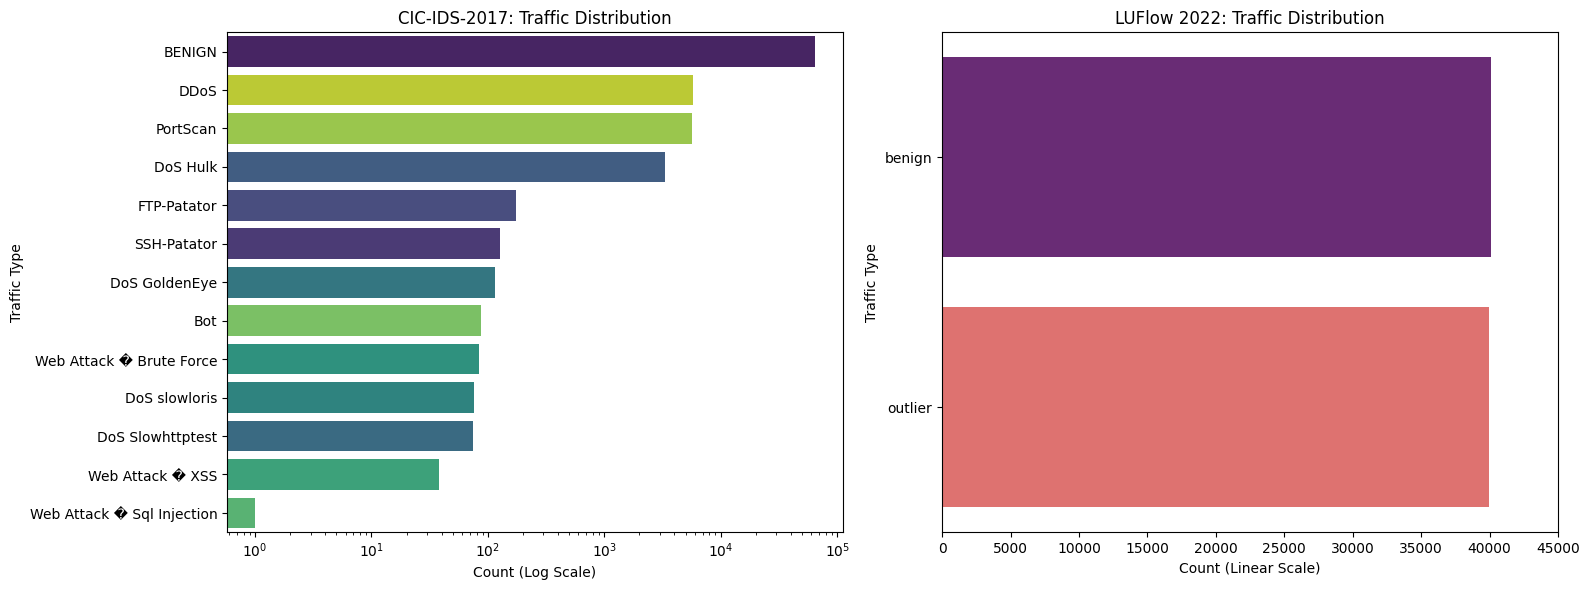

EDA Figures successfully saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import numpy as np
import os

# Statistical Summary Tables
print("--- 2017 Baseline: First 5 Rows (Truncated) ---")
display(df_2017.iloc[:, :8].head())

print("\n--- 2017 Baseline: Statistical Summary (Mean, Std, Min, Max) ---")
display(df_2017.replace([np.inf, -np.inf], np.nan).describe().T.head(10))

# Visualizations: Class Imbalance Graphs
print("\n--- Generating Target Distribution Graphs ---")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot the 2017 Distribution (Log Scale)
sns.countplot(data=df_2017, y='Label', order=df_2017['Label'].value_counts().index, 
              ax=axes[0], palette='viridis', hue='Label', legend=False)
axes[0].set_title('CIC-IDS-2017: Traffic Distribution')
axes[0].set_xlabel('Count (Log Scale)')
axes[0].set_ylabel('Traffic Type')
axes[0].set_xscale('log') 

# Plot the 2022 LUFlow Distribution (Linear Scale)
if 'label' in df_2022.columns:
    sns.countplot(data=df_2022, y='label', order=df_2022['label'].value_counts().index, 
                  ax=axes[1], palette='magma', hue='label', legend=False)
    axes[1].set_title('LUFlow 2022: Traffic Distribution')
    axes[1].set_xlabel('Count (Linear Scale)')
    axes[1].set_ylabel('Traffic Type')
    axes[1].set_xlim(0, 45000) 

plt.tight_layout()

# Save Figures
print("--- Saving EDA Figures to outputs/figures/ ---")
os.makedirs('../outputs/figures/', exist_ok=True)

# Save as PNG and PDF
plt.savefig('../outputs/figures/eda_target_distributions.png', dpi=300, bbox_inches='tight')
plt.savefig('../outputs/figures/eda_target_distributions.pdf', bbox_inches='tight')

plt.show()

print("EDA Figures successfully saved!")

## 6. Model Execution: DBSCAN on 2017 Baseline
We execute the DBSCAN algorithm on a 20,000-record subset to optimize computational overhead. The algorithm groups dense regions of network traffic into distinct clusters while explicitly isolating sparse, anomalous data points as 'Noise' (labeled as -1).

In [10]:
from sklearn.cluster import DBSCAN

print("--- Running DBSCAN on 2017 Baseline ---")

# Subset the data to prevent RAM overflow during the distance matrix computation
subset_size = 20000
X_sample_2017 = X_scaled_2017[:subset_size]
y_sample_2017 = y_2017.iloc[:subset_size]

# Initialize DBSCAN
# eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
# min_samples: The number of samples in a neighborhood for a point to be considered as a core point.
dbscan_2017 = DBSCAN(eps=2.5, min_samples=15)

print("Fitting model... (This might take a minute depending on your hardware)")
labels_2017 = dbscan_2017.fit_predict(X_sample_2017)

# Calculate results
n_clusters_2017 = len(set(labels_2017)) - (1 if -1 in labels_2017 else 0)
n_noise_2017 = list(labels_2017).count(-1)

print(f"Estimated number of distinct clusters: {n_clusters_2017}")
print(f"Points classified as Noise (Anomalies): {n_noise_2017} ({n_noise_2017/subset_size*100:.2f}%)")

--- Running DBSCAN on 2017 Baseline ---
Fitting model... (This might take a minute depending on your hardware)
Estimated number of distinct clusters: 16
Points classified as Noise (Anomalies): 1094 (5.47%)


## 7. Model Execution: DBSCAN on LUFlow 2022
We apply the identical clustering parameters (`eps=2.5`, `min_samples=15`) to the modern telemetry. This allows us to observe how the algorithm responds to the increased feature drift and background noise inherent in real-world honeypot captures compared to a controlled lab environment.

In [11]:
print("--- Running DBSCAN on 2022 Real-World Telemetry ---")

# Subset the modern data to match the baseline size
X_sample_2022 = X_scaled_2022[:subset_size]

# Initialize identical DBSCAN parameters to maintain a controlled scientific comparison
dbscan_2022 = DBSCAN(eps=2.5, min_samples=15)

print("Fitting model... (This might take a minute)")
labels_2022 = dbscan_2022.fit_predict(X_sample_2022)

# Calculate results
n_clusters_2022 = len(set(labels_2022)) - (1 if -1 in labels_2022 else 0)
n_noise_2022 = list(labels_2022).count(-1)

print(f"Estimated number of distinct clusters: {n_clusters_2022}")
print(f"Points classified as Noise (Anomalies): {n_noise_2022} ({n_noise_2022/subset_size*100:.2f}%)")

--- Running DBSCAN on 2022 Real-World Telemetry ---
Fitting model... (This might take a minute)
Estimated number of distinct clusters: 7
Points classified as Noise (Anomalies): 322 (1.61%)


## 8. Cluster Visualization via Principal Component Analysis (PCA)
Because our feature matrices contain high dimensionality (78 and 15 features, respectively), direct visualization is impossible. We utilize Principal Component Analysis (PCA) to project the data onto a 2D plane, allowing us to visually inspect the density and separation of the DBSCAN-generated clusters. Noise points are highlighted to demonstrate the algorithm's anomaly detection capability.

--- Reducing Dimensionality for Visualization (PCA) ---
--- Generating Cluster Maps ---
--- Saving High-Resolution Figures to outputs/figures/ ---


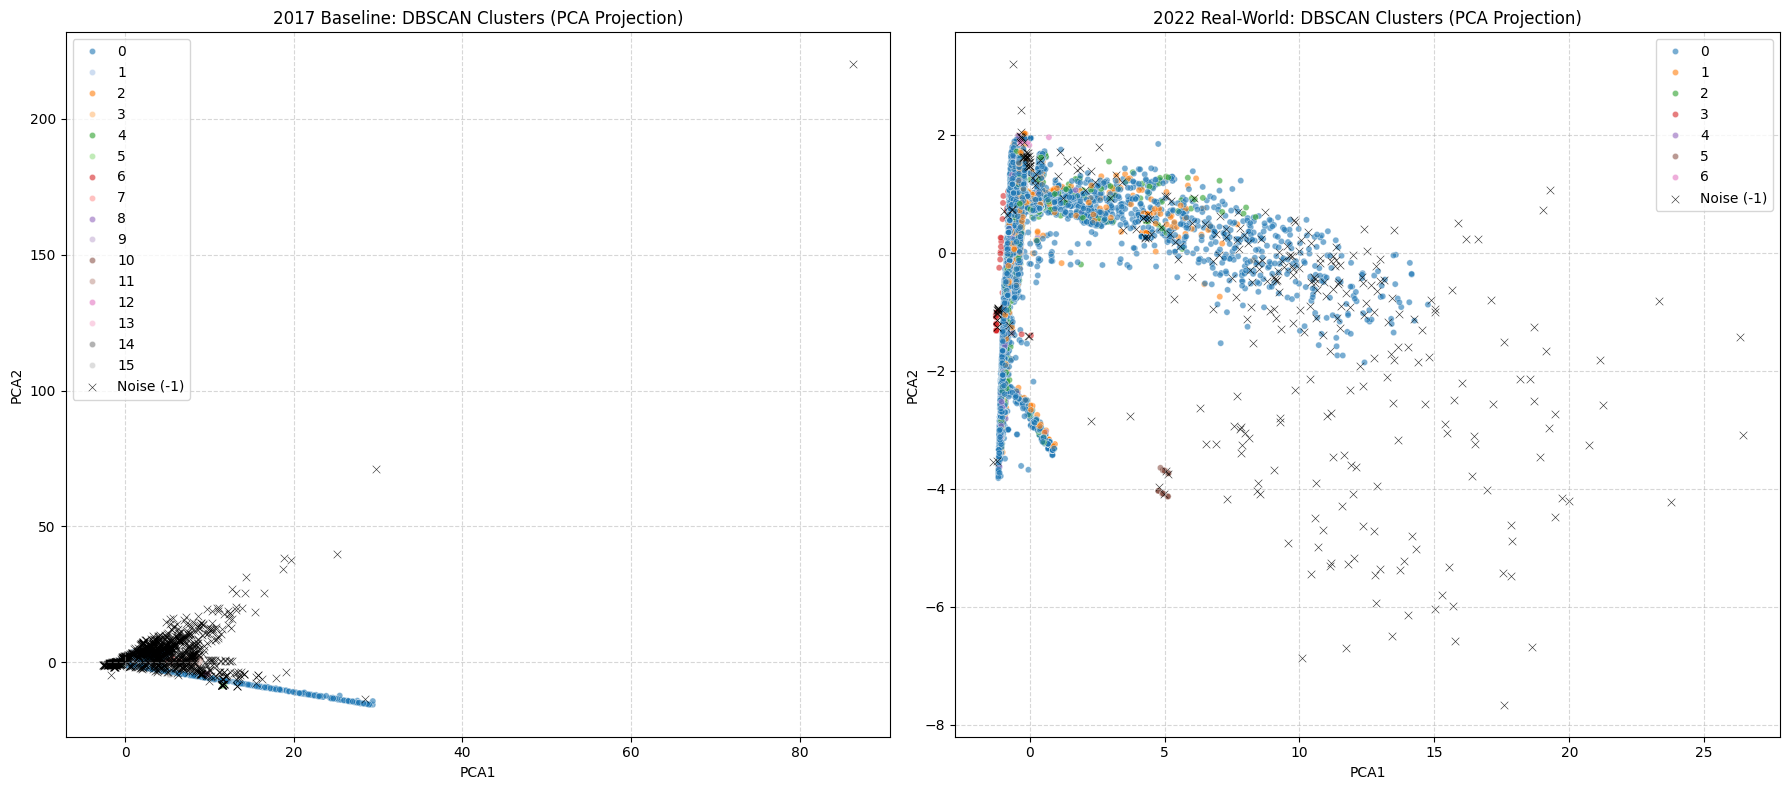

Figures successfully saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import pandas as pd
import os

print("--- Reducing Dimensionality for Visualization (PCA) ---")

# Squash 2017 data down to 2 dimensions
pca_2017 = PCA(n_components=2)
X_pca_2017 = pca_2017.fit_transform(X_sample_2017)
df_pca_2017 = pd.DataFrame(data=X_pca_2017, columns=['PCA1', 'PCA2'])
df_pca_2017['Cluster'] = labels_2017

# Squash 2022 data down to 2 dimensions
pca_2022 = PCA(n_components=2)
X_pca_2022 = pca_2022.fit_transform(X_sample_2022)
df_pca_2022 = pd.DataFrame(data=X_pca_2022, columns=['PCA1', 'PCA2'])
df_pca_2022['Cluster'] = labels_2022

print("--- Generating Cluster Maps ---")
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 2017 Baseline
sns.scatterplot(
    data=df_pca_2017[df_pca_2017['Cluster'] != -1], 
    x='PCA1', y='PCA2', hue='Cluster', palette='tab20', 
    alpha=0.6, s=20, ax=axes[0], legend='full'
)
sns.scatterplot(
    data=df_pca_2017[df_pca_2017['Cluster'] == -1], 
    x='PCA1', y='PCA2', color='black', 
    alpha=0.8, s=30, label='Noise (-1)', ax=axes[0], marker='x'
)
axes[0].set_title('2017 Baseline: DBSCAN Clusters (PCA Projection)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2022 LUFlow
sns.scatterplot(
    data=df_pca_2022[df_pca_2022['Cluster'] != -1], 
    x='PCA1', y='PCA2', hue='Cluster', palette='tab10', 
    alpha=0.6, s=20, ax=axes[1], legend='full'
)
sns.scatterplot(
    data=df_pca_2022[df_pca_2022['Cluster'] == -1], 
    x='PCA1', y='PCA2', color='black', 
    alpha=0.8, s=30, label='Noise (-1)', ax=axes[1], marker='x'
)
axes[1].set_title('2022 Real-World: DBSCAN Clusters (PCA Projection)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# Save High-Resolution Figures
print("--- Saving High-Resolution Figures to outputs/figures/ ---")
os.makedirs('../outputs/figures/', exist_ok=True)

# Save as PNG
plt.savefig('../outputs/figures/dbscan_pca_comparison.png', dpi=300, bbox_inches='tight')

# Save as PDF
plt.savefig('../outputs/figures/dbscan_pca_comparison.pdf', bbox_inches='tight')

# Display it in the notebook
plt.show()

print("Figures successfully saved!")

## 9. Quantitative Evaluation (Silhouette Score)
While PCA provides visual intuition, we must quantitatively evaluate the cohesion and separation of the discovered clusters. We compute the Silhouette Score for both datasets. Noise points (labeled as -1) are filtered out prior to calculation to accurately measure the density of the identified attack profiles.

In [15]:
from sklearn.metrics import silhouette_score

print("--- Calculating Performance Metrics (Silhouette Score) ---")

# Evaluate 2017 Baseline
# We create a 'mask' to filter out the noise points (-1) so they don't skew the cluster cohesion math
mask_2017 = labels_2017 != -1
# Calculate the score only on points that were successfully clustered
sil_2017 = silhouette_score(X_sample_2017[mask_2017], labels_2017[mask_2017])

# Evaluate 2022 Real-World Data
mask_2022 = labels_2022 != -1
sil_2022 = silhouette_score(X_sample_2022[mask_2022], labels_2022[mask_2022])

# Display Results
print(f"2017 Baseline Silhouette Score:  {sil_2017:.4f}")
print(f"2022 Real-World Silhouette Score: {sil_2022:.4f}")

print("\nInterpretation:")
if sil_2017 > sil_2022:
    print("-> The 2017 baseline exhibits higher cluster density and separation.")
    print("-> This mathematically confirms that modern real-world attacks (2022) overlap significantly with normal traffic, making evasion easier.")
else:
    print("-> The 2022 dataset exhibits higher structural clustering.")

--- Calculating Performance Metrics (Silhouette Score) ---
2017 Baseline Silhouette Score:  0.2921
2022 Real-World Silhouette Score: 0.3735

Interpretation:
-> The 2022 dataset exhibits higher structural clustering.


## 10. Model Preservation
To ensure reproducibility, we serialize and save the fitted DBSCAN models. Note that as a transductive clustering algorithm, DBSCAN does not naturally support the `.predict()` method for unseen data; therefore, these saved models serve to preserve the experimental state and core sample indices for future auditing.

In [16]:
import joblib
import os

print("--- Serializing and Saving Machine Learning Models ---")

# Ensure the models directory exists
os.makedirs('../outputs/models/', exist_ok=True)

# Save the 2017 Model
model_path_2017 = '../outputs/models/dbscan_model_2017.pkl'
joblib.dump(dbscan_2017, model_path_2017)
print(f"2017 Baseline Model saved to: {model_path_2017}")

# Save the 2022 Model
model_path_2022 = '../outputs/models/dbscan_model_2022.pkl'
joblib.dump(dbscan_2022, model_path_2022)
print(f"2022 Real-World Model saved to: {model_path_2022}")

print("\nAll experimental assets successfully preserved.")

--- Serializing and Saving Machine Learning Models ---
2017 Baseline Model saved to: ../outputs/models/dbscan_model_2017.pkl
2022 Real-World Model saved to: ../outputs/models/dbscan_model_2022.pkl

All experimental assets successfully preserved.
